# 02 - Segmentación Dual: Núcleo y Citoplasma
**Proyecto:** Detección Asistida de Leucemia Linfoblástica Aguda (LLA)  
**Dataset:** Segmented (una célula por imagen)  

## Objetivo
Aislar de forma robusta dos estructuras de cada célula:
- **Núcleo:** región púrpura oscura → método de Otsu sobre HSV S preprocesado
- **Citoplasma / célula completa:** región pálida que rodea al núcleo → K-Means

## Estructura del notebook
- **Parte A:** Segmentación del núcleo (Otsu + morfología)
- **Parte B:** Segmentación del citoplasma (K-Means)
- **Parte C:** Validación visual de la segmentación dual sobre todas las clases

## 0. Importación de librerías y rutas

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage


RAW_PATH = Path('../data/raw/Original')
CLASSES  = ['Benign', 'Early', 'Pre', 'Pro']
COLORES  = {'Benign': '#2ecc71', 'Early': '#e74c3c', 'Pre': '#e67e22', 'Pro': '#9b59b6'}

print('Librerías cargadas OK')

Librerías cargadas OK


## 0.1 Función de preprocesamiento (del notebook anterior)
Reutilizamos el pipeline validado: `BGR → HSV → canal S → Mediana`

In [2]:
def preprocesamiento(img_path, filtro='mediana', ksize=5):
    """
    Pipeline completo de preprocesamiento:
      1. Carga imagen
      2. Convierte a HSV y extrae canal S
      3. Aplica filtro de ruido mediana
    Retorna: imagen original RGB, canal S sin procesar, canal S preprocesado
    """
    img_bgr = cv2.imread(str(img_path))
    
    # Seguro por si alguna ruta se rompe en otra compu
    if img_bgr is None:
        raise FileNotFoundError(f"No se encontró la imagen en: {img_path}")
    

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    canal_s = img_hsv[:,:,1] # Canal S (Saturación - Índice 1)

    if filtro == 'mediana':
        canal_filtrado = cv2.medianBlur(canal_s, ksize)
    elif filtro == 'gaussiano':
        canal_filtrado = cv2.GaussianBlur(canal_s, (ksize, ksize), 0)
    else:
        canal_filtrado = canal_s
        print(f"Filtro '{filtro}' no reconocido. Se devuelve el canal S limpio.")
    
    return img_rgb, canal_s, canal_filtrado



---
# PARTE A — Segmentación del Núcleo

## A.1 Método de Otsu sobre canal HSV S preprocesado
Otsu calcula automáticamente el umbral óptimo que separa el núcleo (oscuro) del resto.

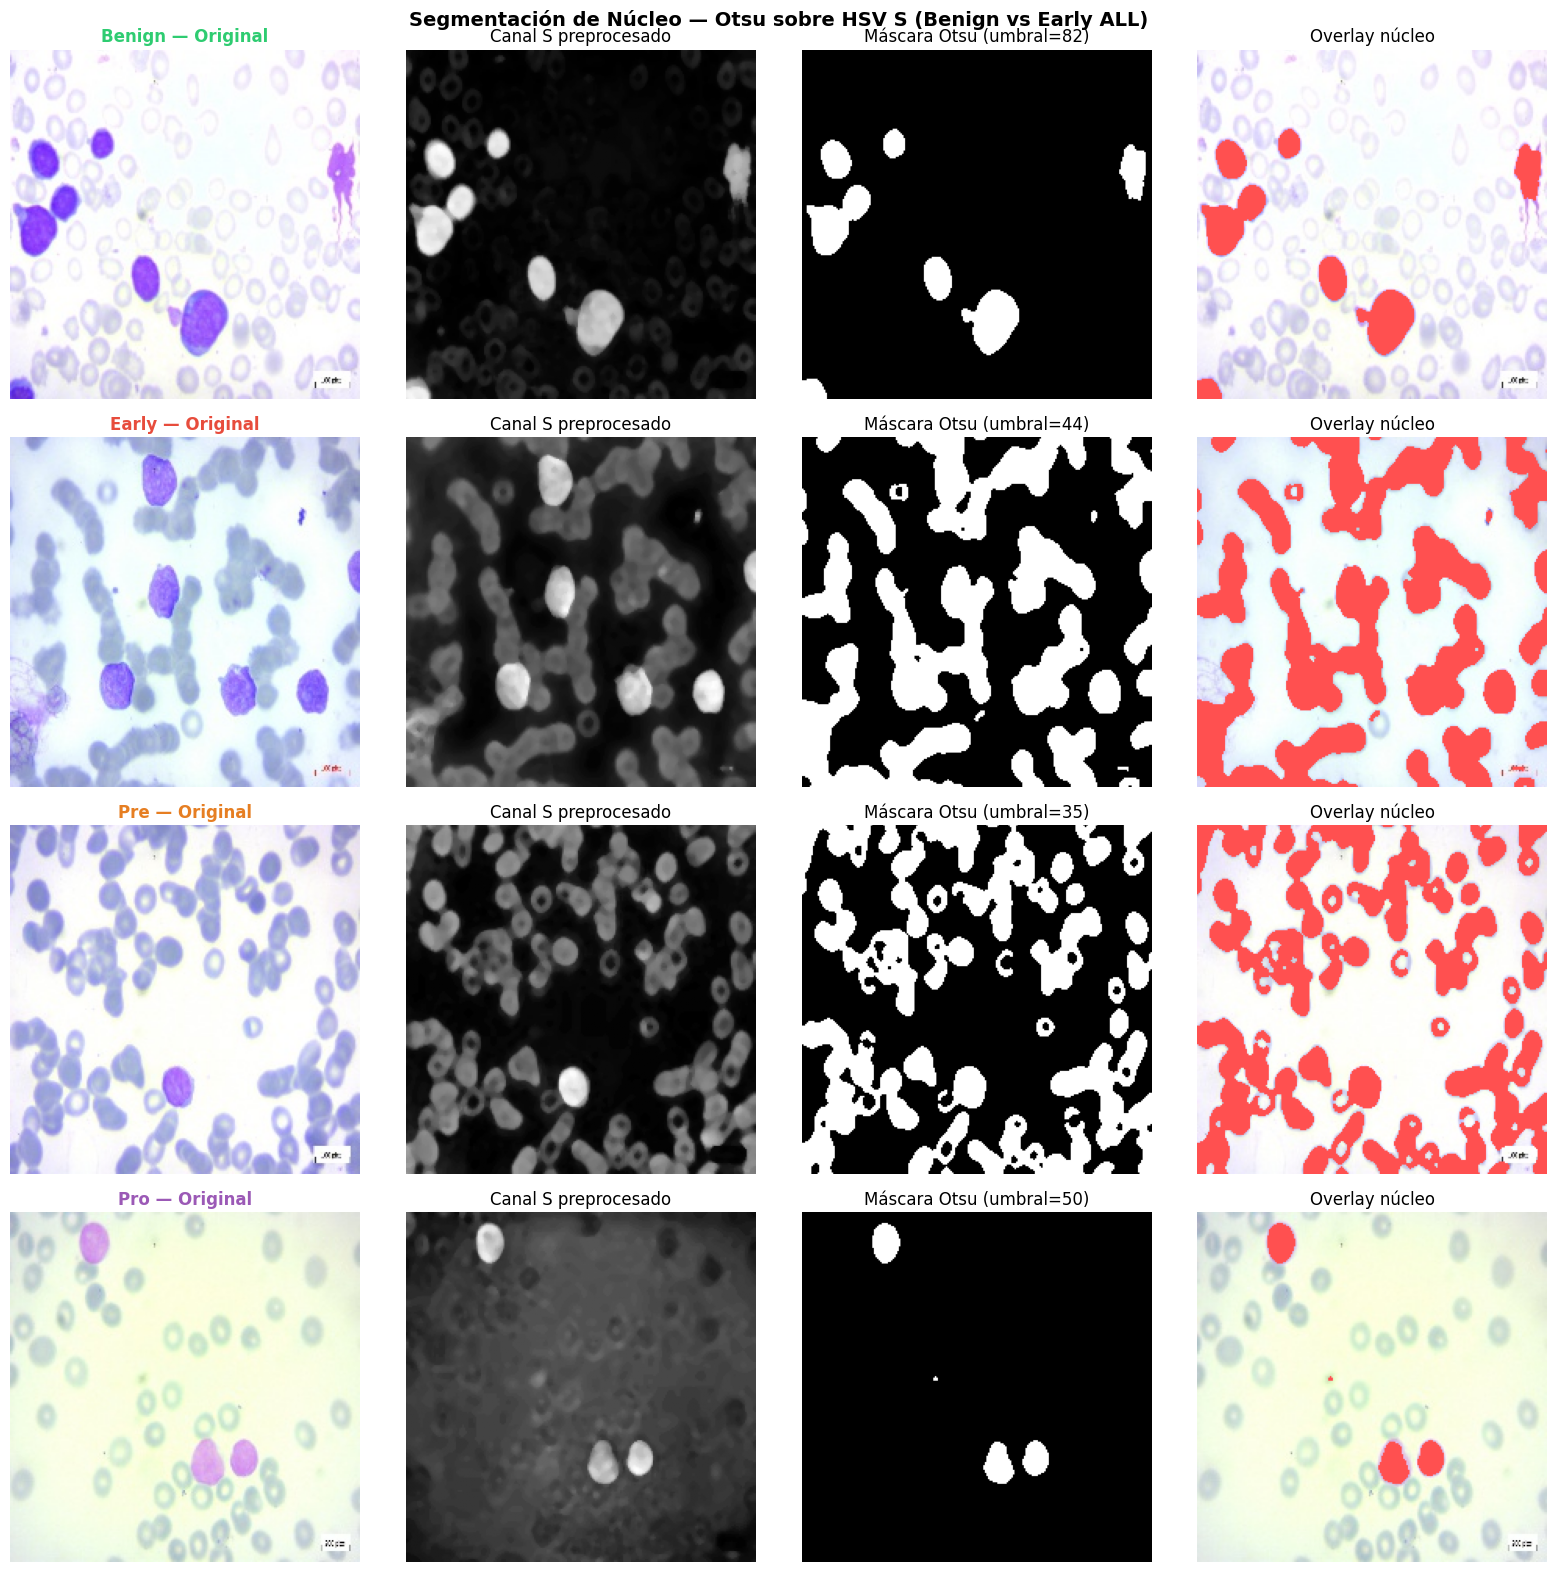

Observar si la máscara cubre el núcleo y no el fondo ni el citoplasma.


In [3]:
# Primer prueba de otsu

def segmentar_nucleo(canal_proc):
    """
    Segmenta el núcleo usando umbralización automática de Otsu.
    El núcleo ya se presenta como la región más brillante en el canal S preprocesado.
    Retorna: la máscara binaria del núcleo y el valor de umbral calculado.
    """
    # Aplicamos Otsu directo (sin invertir) porque el núcleo ya es blanco en el Canal S
    umbral, mascara = cv2.threshold(
        canal_proc, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    return mascara, umbral


# Probar con una imagen de cada clase
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Segmentación de Núcleo — Otsu sobre HSV S (Benign vs Early ALL)', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    img_path = list((RAW_PATH / cls).glob('*.jpg'))[0]
    img_rgb, canal_s_raw, canal_s_proc = preprocesamiento(img_path)
    mascara_nucleo, umbral = segmentar_nucleo(canal_s_proc)

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'{cls} — Original', color=COLORES[cls], fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(canal_s_proc, cmap='gray')
    axes[row, 1].set_title('Canal S preprocesado')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(mascara_nucleo, cmap='gray')
    axes[row, 2].set_title(f'Máscara Otsu (umbral={umbral:.0f})')
    axes[row, 2].axis('off')

    # Overlay: máscara sobre imagen original
    overlay = img_rgb.copy()
    overlay[mascara_nucleo > 0] = [255, 80, 80]
    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title('Overlay núcleo')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.show()
print('Observar si la máscara cubre el núcleo y no el fondo ni el citoplasma.')

En Benign y Pro las máscaras binarias están super limpias, aislando los nucleos de los globulos rojos. Sin embargo en Early y Pre hay fugas de segmenación, ya no se distinguen los nucleos. Asi a continuación mejoraremos otsu

NO SE CREO QUE ESTO VIENE DE CLASIFICAR QUE SIRVE O NO

In [4]:
for cls in CLASSES:
    imgs = list((RAW_PATH / cls).glob('*.jpg'))
    negras = [p for p in imgs if cv2.imread(str(p)).mean() < 5]
    print(f'{cls}: {len(negras)}/{len(imgs)} imágenes negras ({100*len(negras)/len(imgs):.1f}%)')

Benign: 0/504 imágenes negras (0.0%)
Early: 0/985 imágenes negras (0.0%)
Pre: 0/963 imágenes negras (0.0%)
Pro: 0/804 imágenes negras (0.0%)


## A.2 Morfología matemática sobre la máscara del núcleo
- **Apertura:** elimina artefactos pequeños (plaquetas, ruido)
- **Cierre:** rellena huecos internos del núcleo
- **Relleno de agujeros:** consolida la máscara final

Como el canal S nos da un contraste excelente en los núcleos (valores altos) y los glóbulos rojos quedan en un gris muy tenue (valores bajos), podemos forzar un umbral adaptativo o un piso mínimo. En lugar de dejar a Otsu bajar hasta 35 o 44 en las imágenes ruidosas, le ponemos un límite inferior (por ejemplo, que el umbral nunca sea menor a 70). Esto hace que el fondo se vuelva negro inmediatamente, aislando los núcleos desde el principio. Y luego con los núcleos ya separados del fondo, la apertura eliminará los pequeños artefactos sueltos y el cierre consolidará el interior del núcleo a la perfección.

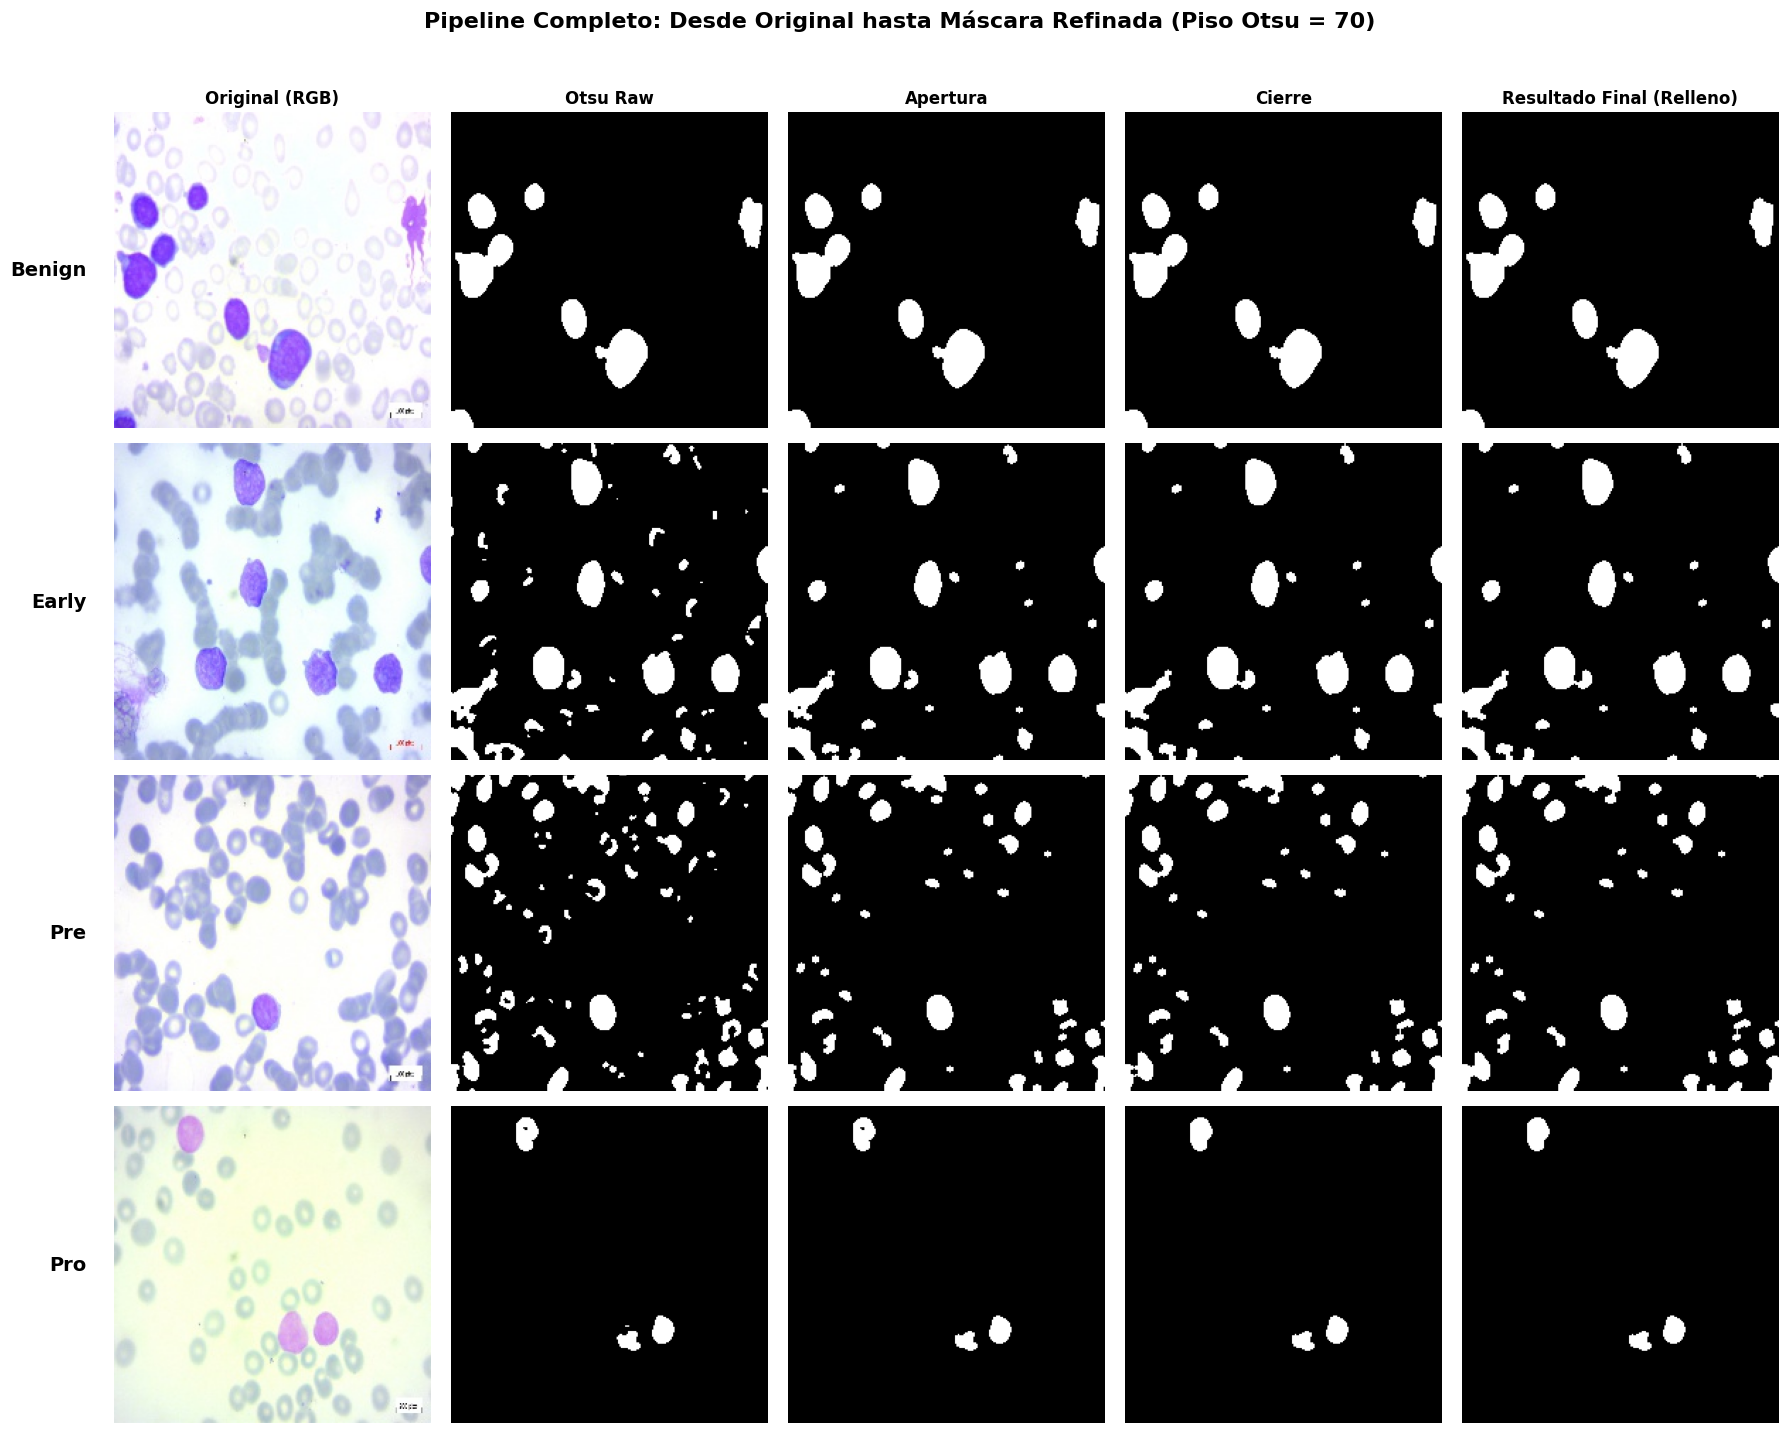

In [5]:
def segmentar_nucleo_otsu(canal_proc, umbral_minimo=70):
    """
    Segmenta el núcleo usando umbralización de Otsu con un piso de seguridad.
    Evita que el umbral baje demasiado en imágenes con ruido de glóbulos rojos.
    """
    # 1. Calculamos Otsu estándar
    umbral_otsu, mascara_otsu = cv2.threshold(
        canal_proc, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # 2. Control de seguridad: Si Otsu calculó un umbral muy bajo, forzamos el mínimo
    if umbral_otsu < umbral_minimo:
        # Re-calculamos usando el umbral fijo de seguridad
        _, mascara = cv2.threshold(canal_proc, umbral_minimo, 255, cv2.THRESH_BINARY)
        umbral_final = umbral_minimo
    else:
        mascara = mascara_otsu
        umbral_final = umbral_otsu
        
    return mascara, umbral_final


def refinar_mascara_nucleo(mascara, kernel_size=5):
    """
    Aplica operaciones morfológicas para limpiar la máscara del núcleo:
    1. Apertura: elimina pequeños artefactos y puentes finos.
    2. Cierre: rellena huecos internos en el núcleo.
    3. Relleno de agujeros con SciPy: consolida la máscara final.
    """
    # Usamos un elemento estructurante elíptico (ideal para formas redondeadas de núcleos)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # 1. Apertura (Erosión + Dilatación) - Limpia ruidos externos
    apertura = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    
    # 2. Cierre (Dilatación + Erosión) - Conecta componentes del mismo núcleo
    cierre = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, kernel)
    
    # 3. Relleno de agujeros internos (SciPy ndimage)
    relleno = ndimage.binary_fill_holes(cierre).astype(np.uint8) * 255
    
    # Retornamos los pasos intermedios para tu gráfico de visualización, 
    # siendo 'relleno' el resultado final optimizado.
    return apertura, cierre, relleno



# 1. Configuración de la grilla (4 clases, 5 columnas de procesamiento)
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('Pipeline Completo: Desde Original hasta Máscara Refinada (Piso Otsu = 70)', 
             fontsize=16, fontweight='bold', y=1.02)

# Nombres de las columnas para los títulos de arriba
columnas_titulos = ['Original (RGB)', 'Otsu Raw', 'Apertura', 'Cierre', 'Resultado Final (Relleno)']

for row, cls in enumerate(CLASSES):
    # Tomamos la primera imagen de cada clase
    img_path = list((RAW_PATH / cls).glob('*.jpg'))[0]
    
    # Paso A: Preprocesamiento (Tu pipeline del Canal S)
    img_rgb, canal_s_raw, canal_proc = preprocesamiento(img_path, filtro='mediana', ksize=5)
    
    # Paso B: Segmentación con el NUEVO freno de mano en 70
    mascara_raw, umbral_calc = segmentar_nucleo_otsu(canal_proc, umbral_minimo=70)
    
    # Paso C: Refinamiento morfológico con el kernel elíptico
    apertura, cierre, relleno = refinar_mascara_nucleo(mascara_raw, kernel_size=5)
    
    # Metemos los 5 pasos en una lista para graficarlos en orden
    lista_pasos = [img_rgb, mascara_raw, apertura, cierre, relleno]
    
    for col, paso_img in enumerate(lista_pasos):
        ax = axes[row, col]
        
        # Si es la primera columna es RGB, el resto son máscaras en blanco y negro
        if col == 0:
            ax.imshow(paso_img)
        else:
            ax.imshow(paso_img, cmap='gray')
            
        ax.axis('off')
        
        # Ponemos los títulos de las columnas solo en la primera fila de arriba
        if row == 0:
            ax.set_title(columnas_titulos[col], fontsize=12, fontweight='bold')
            
    # Ponemos el nombre de la clase a la izquierda de todo de cada fila
    axes[row, 0].text(-20, paso_img.shape[0]//2, cls, fontsize=14, 
                      fontweight='bold', va='center', ha='right', rotation=0)

plt.tight_layout()

# Guardamos el éxito en la carpeta processed
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/pipeline_segmentacion_perfecto.png', dpi=150, bbox_inches='tight')
plt.show()

Ahora si guardamos los datos en la carpeta data/processed

## A.3 Selección del componente más grande (núcleo principal)
Si quedan múltiples regiones, nos quedamos solo con la más grande (el núcleo real).

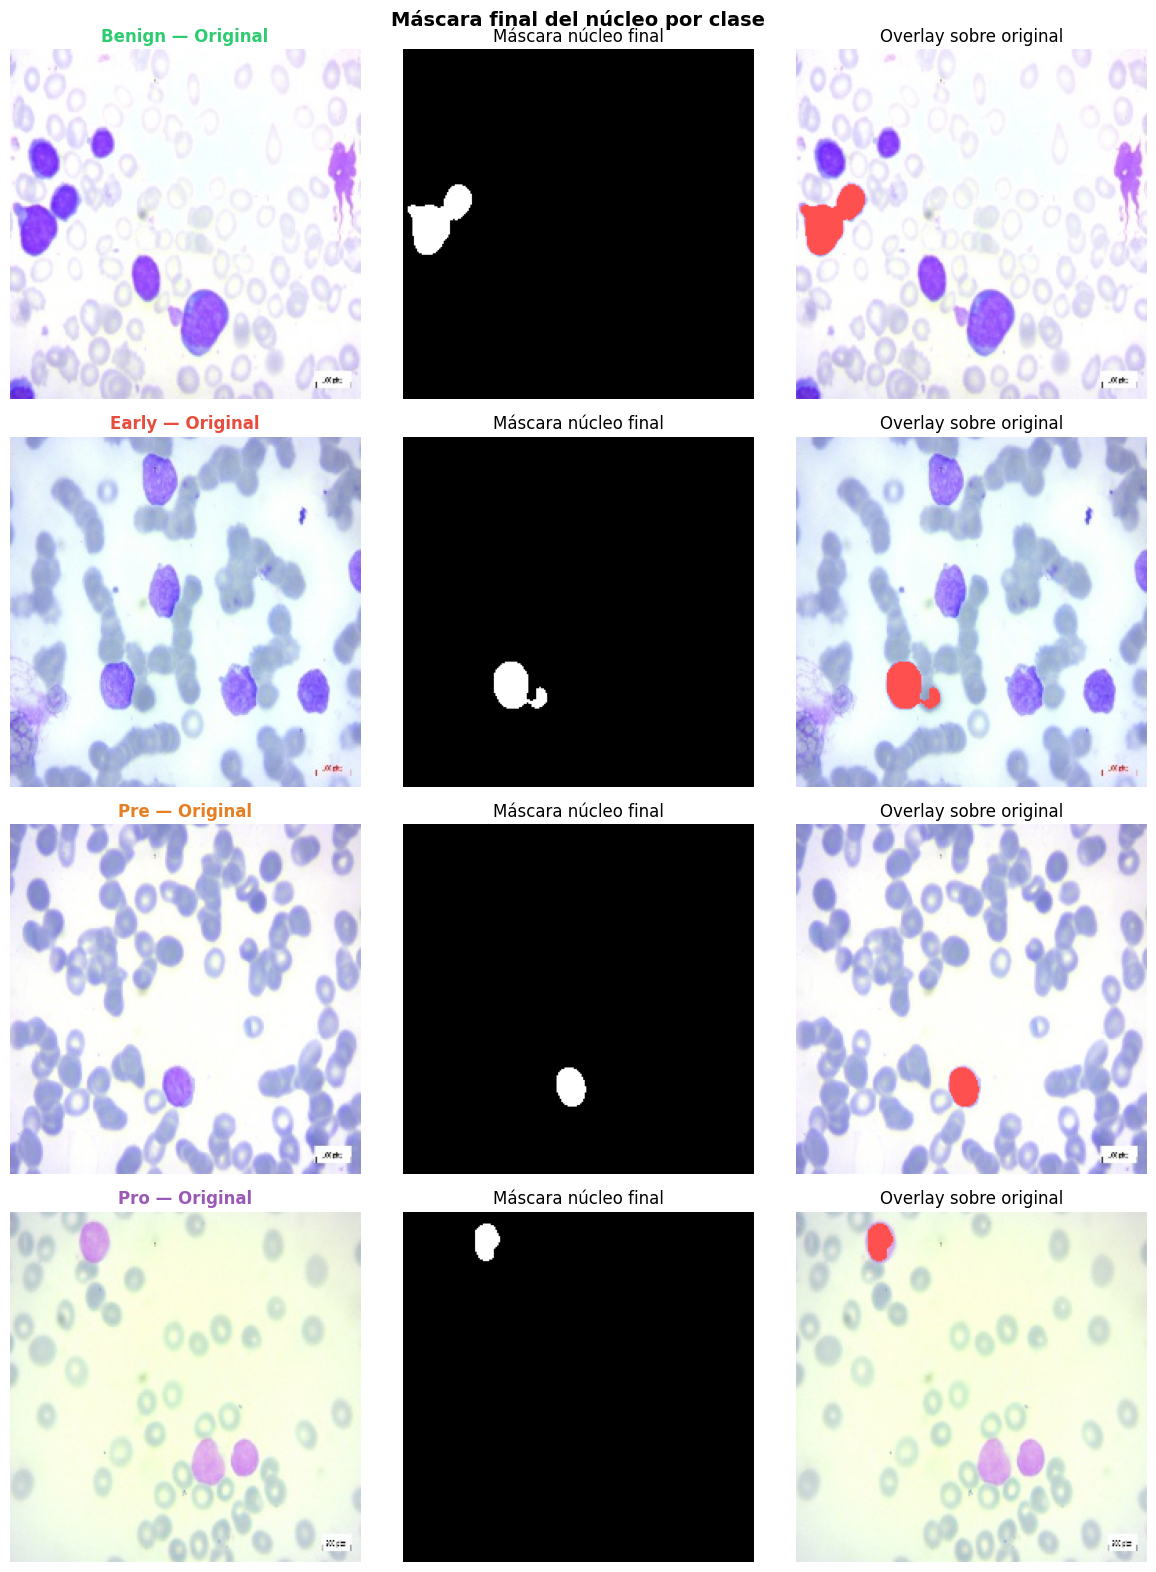

Si la máscara cubre bien el núcleo en todas las clases, pasamos a la Parte B.


In [6]:
def extraer_nucleo_principal(mascara_rellena):
    """
    De la máscara morfológica, extrae únicamente el componente
    conectado más grande (el núcleo principal).
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mascara_rellena, connectivity=8
    )
    if num_labels <= 1:
        return mascara_rellena  # sin componentes, devolver tal cual

    # El label 0 es el fondo, buscamos el más grande entre los demás
    areas = stats[1:, cv2.CC_STAT_AREA]
    idx_mayor = np.argmax(areas) + 1
    mascara_nucleo_final = np.uint8(labels == idx_mayor) * 255
    return mascara_nucleo_final


# Pipeline completo de núcleo: Otsu → Morfología → Componente principal
def get_nucleus_mask(img_path):
    img_rgb, canal_s_raw, canal_s_proc = preprocesamiento(img_path)
    mascara_raw, _      = segmentar_nucleo_otsu(canal_s_proc)
    _, _, relleno       = refinar_mascara_nucleo(mascara_raw)
    mascara_final       = extraer_nucleo_principal(relleno)
    return img_rgb, canal_s_proc, mascara_final


# Verificar en una imagen de cada clase
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Máscara final del núcleo por clase', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    img_path = list((RAW_PATH / cls).glob('*.jpg'))[0]
    img_rgb, canal_s_proc, mascara_nucleo = get_nucleus_mask(img_path)

    overlay = img_rgb.copy()
    overlay[mascara_nucleo > 0] = [255, 80, 80]

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'{cls} — Original', color=COLORES[cls], fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mascara_nucleo, cmap='gray')
    axes[row, 1].set_title('Máscara núcleo final')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Overlay sobre original')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()
print('Si la máscara cubre bien el núcleo en todas las clases, pasamos a la Parte B.')

---
# PARTE B — Segmentación del Citoplasma con K-Means

## B.1 K-Means sobre la imagen RGB
K-Means agrupa los píxeles por color. Con k=3 esperamos obtener: fondo, citoplasma y núcleo.

ValueError: too many values to unpack (expected 2)

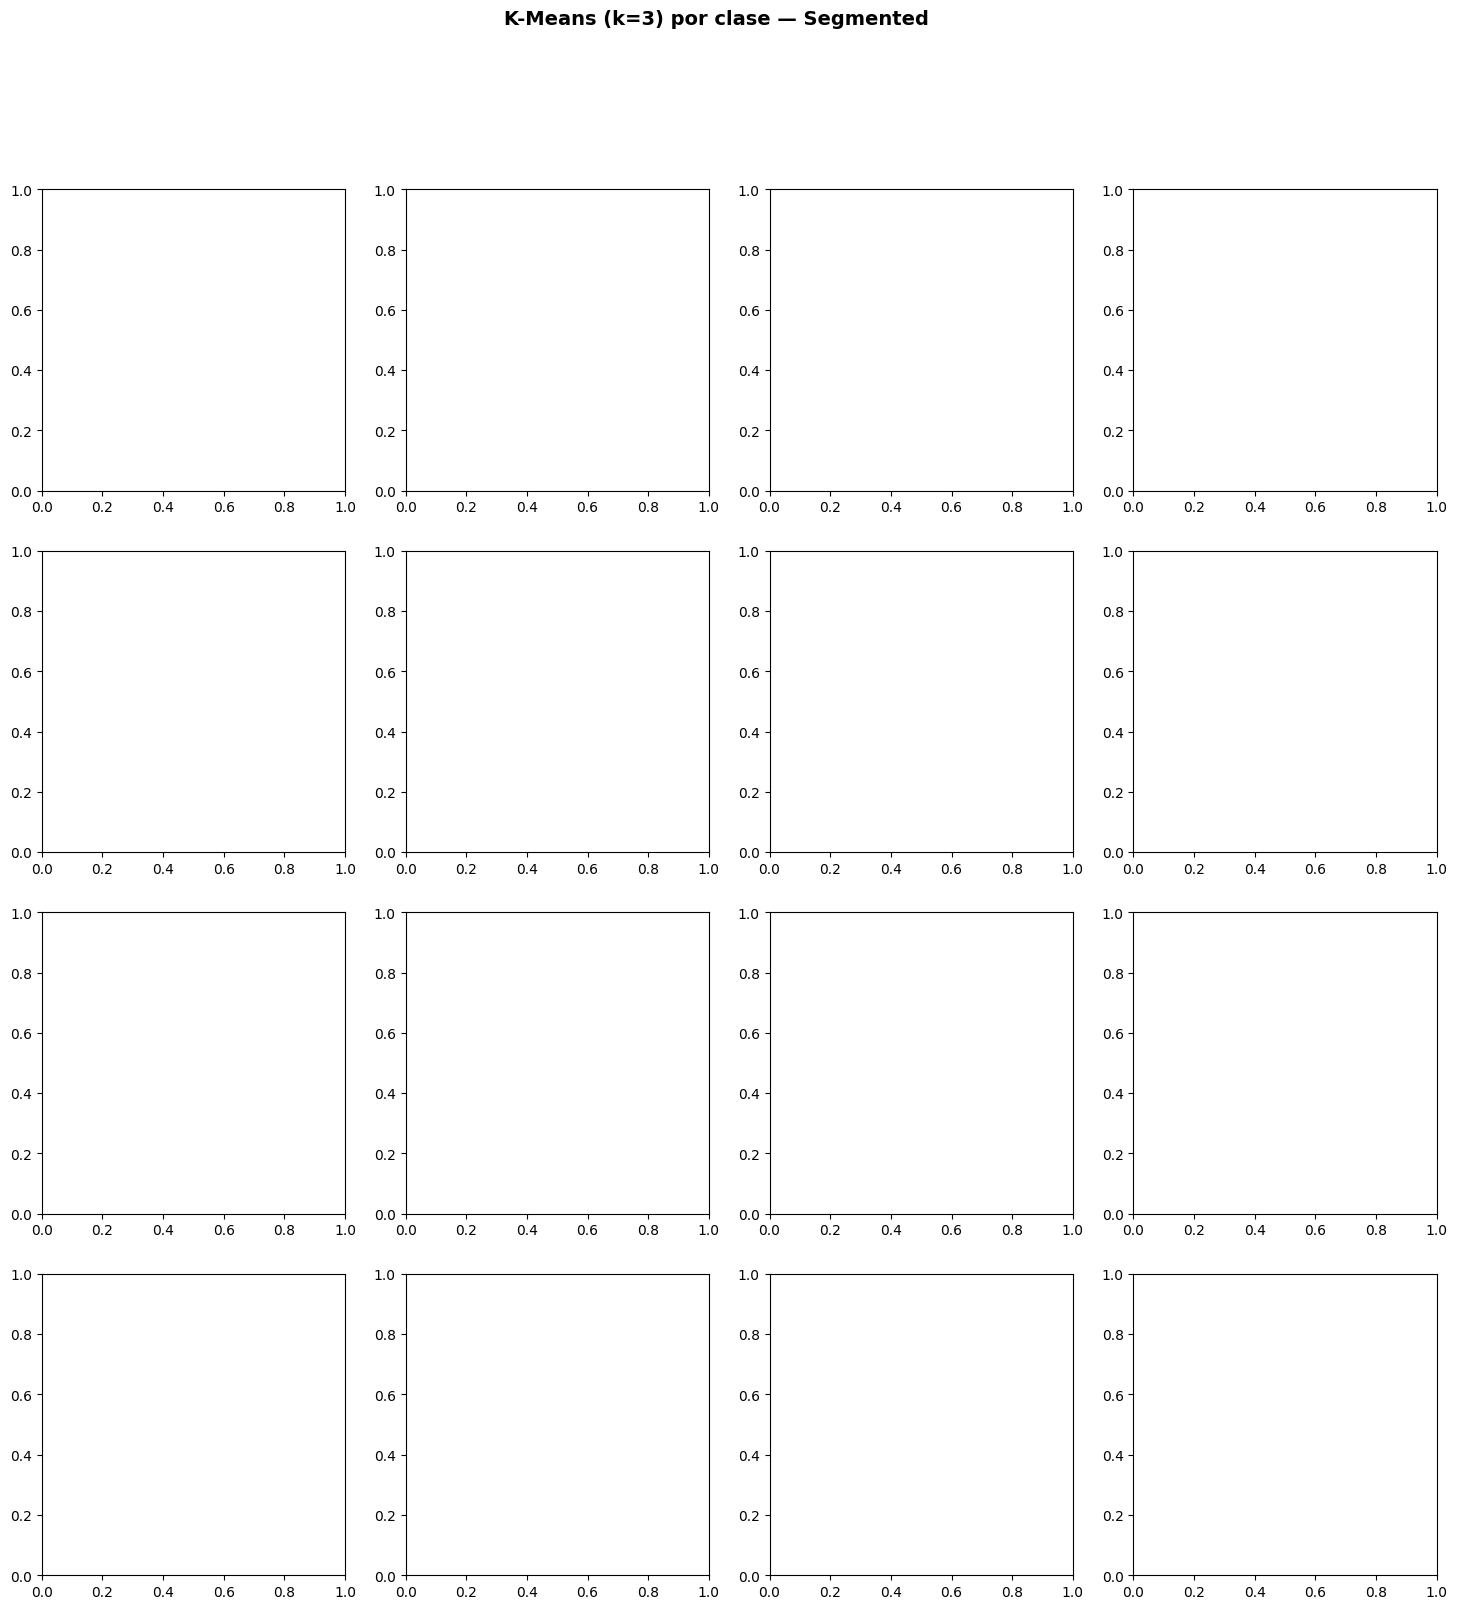

In [7]:
def segmentar_kmeans(img_rgb, k=3):
    """
    Aplica K-Means sobre la imagen RGB para separar:
    fondo / citoplasma / núcleo.
    Retorna la imagen segmentada y las etiquetas por píxel.
    """
    pixeles = img_rgb.reshape(-1, 3).astype(np.float32)

    criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, etiquetas, centros = cv2.kmeans(
        pixeles, k, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS
    )

    centros = np.uint8(centros)
    img_segmentada = centros[etiquetas.flatten()].reshape(img_rgb.shape)
    etiquetas_2d   = etiquetas.reshape(img_rgb.shape[:2])

    return img_segmentada, etiquetas_2d, centros


# Probar K-Means en una imagen de cada clase
fig, axes = plt.subplots(4, 4, figsize=(18, 18))
fig.suptitle('K-Means (k=3) por clase — Segmented', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    img_path = list((RAW_PATH / cls).glob('*.jpg'))[0]
    img_rgb, _ = preprocesamiento(img_path)
    img_seg, etiquetas, centros = segmentar_kmeans(img_rgb, k=3)

    # Ordenar clusters por luminosidad (oscuro=núcleo, medio=citoplasma, claro=fondo)
    brillo = centros.mean(axis=1)
    orden  = np.argsort(brillo)  # [nucleo, citoplasma, fondo]

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'{cls} — Original', color=COLORES[cls], fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img_seg)
    axes[row, 1].set_title('K-Means segmentado')
    axes[row, 1].axis('off')

    # Máscara del cluster más oscuro (núcleo)
    mascara_kmeans_nucleo = np.uint8(etiquetas == orden[0]) * 255
    axes[row, 2].imshow(mascara_kmeans_nucleo, cmap='gray')
    axes[row, 2].set_title('Cluster oscuro (núcleo)')
    axes[row, 2].axis('off')

    # Máscara célula completa (núcleo + citoplasma = clusters 0 y 1)
    mascara_celula = np.uint8((etiquetas == orden[0]) | (etiquetas == orden[1])) * 255
    axes[row, 3].imshow(mascara_celula, cmap='gray')
    axes[row, 3].set_title('Célula completa (N+C)')
    axes[row, 3].axis('off')

plt.tight_layout()
#plt.savefig('../data/processed/segmentacion_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

## B.2 Máscara del citoplasma = célula completa − núcleo
Una vez que tenemos la máscara de célula completa y la del núcleo, el citoplasma es la diferencia.

In [ ]:
def get_cytoplasm_mask(img_rgb, mascara_nucleo, k=3):
    """
    Obtiene la máscara del citoplasma como:
    citoplasma = célula_completa (K-Means) - núcleo (Otsu)
    """
    _, etiquetas, centros = segmentar_kmeans(img_rgb, k=k)

    # Ordenar clusters por brillo
    brillo = centros.mean(axis=1)
    orden  = np.argsort(brillo)

    # Célula completa: clusters oscuro + medio
    mascara_celula = np.uint8((etiquetas == orden[0]) | (etiquetas == orden[1])) * 255

    # Aplicar morfología a la célula completa
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mascara_celula = cv2.morphologyEx(mascara_celula, cv2.MORPH_CLOSE, kernel)
    mascara_celula = ndimage.binary_fill_holes(mascara_celula).astype(np.uint8) * 255

    # Citoplasma = célula − núcleo
    mascara_citoplasma = cv2.subtract(mascara_celula, mascara_nucleo)

    return mascara_celula, mascara_citoplasma


# Visualizar segmentación dual completa por clase
fig, axes = plt.subplots(4, 5, figsize=(22, 18))
fig.suptitle('Segmentación Dual: Núcleo + Citoplasma por clase', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    img_path = list((RAW_PATH / cls).glob('*.jpg'))[0]
    img_rgb, canal_proc, mascara_nucleo = get_nucleus_mask(img_path)
    mascara_celula, mascara_citoplasma  = get_cytoplasm_mask(img_rgb, mascara_nucleo)

    # Overlay con colores: núcleo=rojo, citoplasma=azul
    overlay = img_rgb.copy()
    overlay[mascara_nucleo > 0]     = [255, 80,  80]   # rojo = núcleo
    overlay[mascara_citoplasma > 0] = [80,  80,  255]  # azul = citoplasma

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'{cls} — Original', color=COLORES[cls], fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mascara_nucleo, cmap='gray')
    axes[row, 1].set_title('Máscara Núcleo')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(mascara_celula, cmap='gray')
    axes[row, 2].set_title('Máscara Célula')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(mascara_citoplasma, cmap='gray')
    axes[row, 3].set_title('Máscara Citoplasma')
    axes[row, 3].axis('off')

    axes[row, 4].imshow(overlay)
    axes[row, 4].set_title('Overlay dual (R=núcleo, B=citoplasma)')
    axes[row, 4].axis('off')

plt.tight_layout()
#plt.savefig('../data/processed/segmentacion_dual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Verificar que el rojo cubre el núcleo y el azul el citoplasma en todas las clases.')

---
# PARTE C — Validación Visual sobre múltiples imágenes

## C.1 Verificar segmentación en 3 imágenes por clase
Un resultado bueno en una sola imagen puede ser casualidad. Verificamos en varias.

In [ ]:
N_MUESTRAS = 3

fig, axes = plt.subplots(4 * N_MUESTRAS, 3, figsize=(12, 4 * 4 * N_MUESTRAS // 3))
fig.suptitle(f'Validación: segmentación dual en {N_MUESTRAS} imágenes por clase', 
             fontsize=13, fontweight='bold')

fila = 0
for cls in CLASSES:
    imgs = list((RAW_PATH / cls).glob('*.jpg'))[:N_MUESTRAS]
    for img_path in imgs:
        img_rgb, _, mascara_nucleo    = get_nucleus_mask(img_path)
        mascara_celula, mascara_citoplasma = get_cytoplasm_mask(img_rgb, mascara_nucleo)

        overlay = img_rgb.copy()
        overlay[mascara_nucleo > 0]     = [255, 80, 80]
        overlay[mascara_citoplasma > 0] = [80, 80, 255]

        axes[fila, 0].imshow(img_rgb)
        axes[fila, 0].set_title(f'{cls} — Original', color=COLORES[cls], fontsize=9)
        axes[fila, 0].axis('off')

        axes[fila, 1].imshow(mascara_nucleo, cmap='gray')
        axes[fila, 1].set_title('Núcleo', fontsize=9)
        axes[fila, 1].axis('off')

        axes[fila, 2].imshow(overlay)
        axes[fila, 2].set_title('Overlay dual', fontsize=9)
        axes[fila, 2].axis('off')

        fila += 1

plt.tight_layout()
#plt.savefig('../data/processed/validacion_segmentacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Si la segmentación es consistente en todas las clases, el pipeline está listo.')
print('Próximo paso: 03_feature_extraction_analysis.ipynb')